# Creating an Reservoir Artificial Metabolic (AMN) Reservoir with an experimental medium ($C_{med}$)

## Set up environment

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Imports
import os
import sys

# Working directory
DIRECTORY = './'
print(os.listdir(DIRECTORY)) # prints the files


['.git', 'Duplicate_Model.ipynb', '.gitignore', 'Figures.ipynb', 'experiments', 'Build_Model_ANN_Dense.ipynb', 'Build_Dataset.ipynb', 'Figures', 'Result', 'Tutorial.ipynb', 'Build_Model_MM.ipynb', 'pyproject.toml', 'Reservoir', 'environment_amn.yml', 'Build_Experimental.ipynb', 'Dataset_model', 'uv.lock', 'Build_Dataset_KO.ipynb', 'Build_Model_RC.ipynb', 'environment_amn_light.yml', 'Library', 'Tutorial_Cmed.ipynb', 'README.md', 'Build_Model_AMN.ipynb', 'Dataset_experimental', 'Build_Model_AMN_KO.ipynb', '.venv', 'LICENSE', 'Tutorial_Cmed copy.ipynb', 'Dataset_input']


In [2]:
# Check GPU availability

# Set the log level to suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # filter out INFO, WARNING, and ERROR logs

import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPUs: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.15.1
GPUs: 1


In [3]:
def printout(V, Stats, model):
    """
    Printout function to use in the tutorial
    """
    # printing Stats
    print("R2 = %.2f (+/- %.2f) Constraint = %.2f (+/- %.2f)" % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    Vout = tf.convert_to_tensor(np.float32(model.Y))
    Loss_norm, dLoss = Loss_Vout(V, model.Pout, Vout)
    print('Loss Targets', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_SV(V, model.S)
    print('Loss SV', np.mean(Loss_norm))
    Vin = tf.convert_to_tensor(np.float32(model.X))
    Pin = tf.convert_to_tensor(np.float32(model.Pin))
    if Vin.shape[1] == model.S.shape[1]: # special case
        Vin  = tf.linalg.matmul(Vin, tf.transpose(Pin), b_is_sparse=True)
    Loss_norm, dLoss = Loss_Vin(V, model.Pin, Vin, model.mediumbound, model)
    print('Loss Vin bound', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_Vpos(V, model)
    print('Loss V positive', np.mean(Loss_norm))

## Step 1: Prepare Genome-Scale Model

A requirement for neural computations with metabolic networks using AMNs is the positivity of all fluxes. This means duplicating the reversible reactions in the Genome-Scale Model (GEM) used, making it irreversible.

The following steps transform an SBML model into an *AMN-compatible*  model where: **all exchange reactions are possible in both ways, and reversible internal reactions are duplicated for each way**.

In this transformed model, suffixes are added to 'transfer' reactions (those with different compartments* in their reactants and products): 
 - `i`: inflowing reactions
    - `None --> e --> p --> c --> m`
 - `o`: outflowing reactions
     - `m --> c --> p --> e --> None`

    Example:
    $\text{glc}\_e \rightarrow \text{glc}\_c$, has the suffix `_i` 

If the change in compartment is balanced, or doesn't exist, the suffixes will correspond to the default way of the reaction
- `f`: forward 
- `r`: reverse

    Example: $$\text{g6p}\_c \leftrightarrow \text{f6p}\_c$$, will be broken down into 2 reactions with the suffix `_f` and `_i` 

If the reaction is shows inflow/outflow simultaneously (symport/antiport reactions), the small molecules (such as protons, `h_p`, `h_c`, `h2o_c`) are ignored, identifying them with `unsignificant_mols`.

---
***Compartments**:
$$\text{Environment (None)} \rightarrow \text{Extracellular (e)} \rightarrow \text{Periplasm (p)} \rightarrow \text{Cytosol (c)} \rightarrow \text{Mitochondria (m)}$$

In [4]:
# Import the module
from Library.Duplicate_Model import *

In [5]:
# iML1515 model
model_path = "Dataset_input/iML1515.xml"
url = "http://bigg.ucsd.edu/static/models/iML1515.xml"
response = requests.get(url)
open(model_path, "wb").write(response.content)
model = cobra.io.read_sbml_model(model_path)

In [6]:
# Boundary reactions
# reactions that introduce or remove matter in the system (inflows, outflows)
boundary_rxns = model.boundary
print(f"Total number of boundary reactions: {len(boundary_rxns)}")
print("First 5 reactions:")
for reaction in boundary_rxns[:5]:
    print(reaction)
    
# Medium reactions
# reactions in .boundary that are reversible
medium_rxns = model.medium
print(f"\nTotal number of medium reactions: {len(medium_rxns)}")
print(f"All medium reactions: {medium_rxns}")


Total number of boundary reactions: 337
First 5 reactions:
EX_pi_e: pi_e <=> 
EX_co2_e: co2_e <=> 
EX_met__L_e: met__L_e --> 
EX_metsox_S__L_e: metsox_S__L_e --> 
EX_acgam_e: acgam_e --> 

Total number of medium reactions: 24
All medium reactions: {'EX_pi_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_h_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_zn2_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_sel_e': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_so4_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_k_e': 1000.0, 'EX_na1_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_tungs_e': 1000.0, 'EX_slnt_e': 1000.0}


In [7]:
io_dict = {"_i": [(None, "e"), (None, "c"), ("e","p"), ("p", "c"), ("e", "c"), ("c", "m"), ("p", "m")],
           "_o": [("c", None), ("e", None), ("p", "e"), ("c", "p"), ("c", "e"), ("m", "c"), ("m", "p")]}

unsignificant_mols = ["h_p", "h_c", "pi_c", "pi_p", "adp_c", "h2o_c", "atp_c"]

# Dictionary counting the reactions in reversible, forward, backward, open 
reac_id_to_io_count_and_way = screen_out_in(model, io_dict, unsignificant_mols)

# Structure of the screening dictionary
print()
print(reac_id_to_io_count_and_way)

{'r': 663, 'f': 2047, 'b': 0, 'o': 2}

{'NDPK5': [{'_i': 0, '_o': 0}, 'r'], 'SHK3Dr': [{'_i': 0, '_o': 0}, 'r'], 'NDPK6': [{'_i': 0, '_o': 0}, 'r'], 'NDPK8': [{'_i': 0, '_o': 0}, 'r'], 'DHORTS': [{'_i': 0, '_o': 0}, 'r'], 'PYNP2r': [{'_i': 0, '_o': 0}, 'r'], 'ICDHyr': [{'_i': 0, '_o': 0}, 'r'], 'DURIPP': [{'_i': 0, '_o': 0}, 'r'], 'ACALD': [{'_i': 0, '_o': 0}, 'r'], 'MAN6PI': [{'_i': 0, '_o': 0}, 'r'], 'TRPAS2': [{'_i': 0, '_o': 0}, 'r'], 'ALAR': [{'_i': 0, '_o': 0}, 'r'], 'ALATA_L': [{'_i': 0, '_o': 0}, 'r'], 'PPM': [{'_i': 0, '_o': 0}, 'r'], 'ASPTA': [{'_i': 0, '_o': 0}, 'r'], 'EX_pi_e': [{'_i': 0, '_o': 1}, 'r'], 'EX_co2_e': [{'_i': 0, '_o': 1}, 'r'], 'A5PISO': [{'_i': 0, '_o': 0}, 'r'], 'EX_met__L_e': [{'_i': 0, '_o': 1}, 'f'], 'GTHOr': [{'_i': 0, '_o': 0}, 'r'], 'ILETA': [{'_i': 0, '_o': 0}, 'r'], 'EX_metsox_S__L_e': [{'_i': 0, '_o': 1}, 'f'], 'VALTA': [{'_i': 0, '_o': 0}, 'r'], 'IPPMIb': [{'_i': 0, '_o': 0}, 'r'], 'ORPT': [{'_i': 0, '_o': 0}, 'r'], 'PSCVT': [{'_i': 0, '_o': 0}, '

In [8]:
# Use the dictionary to generate the AMN-compatible model
new_model = duplicate_model(model, reac_id_to_io_count_and_way)

The default model had 2712 reactions and the duplicated-reactions model has 3682 reactions.


In [9]:
# all non-default medium exchange reactions with UB=0 are set to 1e-300
# so they still appear in the medium object.
default_med = model.medium
new_med = new_model.medium
correct_med =  correct_duplicated_med(default_med, new_med)
new_model.medium = correct_med

print(f"Default medium: {len(default_med)} compounds\n{default_med}")
print(f"\nCorrected medium: {len(correct_med)} compounds\n{correct_med}")

Default medium: 24 compounds
{'EX_pi_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_h_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_zn2_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_sel_e': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_so4_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_k_e': 1000.0, 'EX_na1_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_tungs_e': 1000.0, 'EX_slnt_e': 1000.0}

Corrected medium: 331 compounds
{'EX_pi_e_i': 1000.0, 'EX_co2_e_i': 1000.0, 'EX_met__L_e_i': 1e-300, 'EX_metsox_S__L_e_i': 1e-300, 'EX_acgam_e_i': 1e-300, 'EX_cellb_e_i': 1e-300, 'EX_crn_e_i': 1e-300, 'EX_hxan_e_i': 1e-300, 'EX_ile__L_e_i': 1e-300, 'EX_chol_e_i': 1e-300, 'EX_fe3_e_i': 1000.0, 'EX_lac__L_e_i': 1e-300, 'EX_leu__L_e_i': 1e-300, 'EX_glcn_e_i': 1e-300, 'EX_no3_e_i': 1e-300, 'EX_h_e_i': 1000.0, 'EX_orn_e_i': 1e-300, 'EX_gln__L_e_i': 1e-300, 'EX_pro__L_e_i': 1e-300, 'EX_gl

In [10]:
# Rebuild indices and pointers in the model if necessary
new_model.repair() 

In [11]:
print("Original model's location: " + model_path)
new_name = model_path[:-4] + "_duplicated" + model_path[-4:]

cobra.io.write_sbml_model(new_model, new_name)
print("Duplicated model's location: " + new_name)

Original model's location: Dataset_input/iML1515.xml
Duplicated model's location: Dataset_input/iML1515_duplicated.xml


## Step 2: Generate `FBA-simulated` training set for Reservoir AMN

An `FBA-simulated` dataset will be generated for the AMN Reservoir with experimental data.
This generation relies on the `Cmed` Dataset, a csv where `rows = conditions` and `cols = exchanges`+`growth_value` 

### 2.1. Using the `Cmed` dataset for creating `X`

\* Process from `Build_Dataset.ipynb` cell 4

\* **TO DO:** Add a pre-processing step for the medium csv. Even though this might already be mapped to GEM reaction names, these names need to have the `_i` suffix. To do this, match the names using `correct_med` from above.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from Library.Build_Dataset import *

# Set parameters
seed = 10
np.random.seed(seed=seed)  # seed for random number generator
cobraname =  'iML1515_duplicated' # name of the model 
mediumname = 'iML1515' # name of the medium file
mediumbound = 'UB' # Exact bound (EB) or upper bound (UB)
expname = 'iML1515_EXP' # name of the experimental dataset for constraints
size, size_i  = 110, 100 # (# of exp conditions, training set size per condition)
reduce = False # Set at True if you want to reduce the model
mediumsize = 38 # number of medium compounds
verbose = True # prints

# Get X from experimental dataset
cobrafile = DIRECTORY+'Dataset_input/'+cobraname # .xml
expfile  = DIRECTORY+'Dataset_input/'+expname # .csv

# Generate a parameter object with the experimental data
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=expfile, 
                        mediumbound=mediumbound, 
                        mediumsize=mediumsize, 
                        method='EXP',
                        verbose=verbose)


medium: ['EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']
levmed: []
valmed: []
ratmed: 0
objective:  ['BIOMASS_Ec_iML1515_core_75p37M']
measurements size:  3682


In [14]:
# Store the medium data 
# (X matrix, where rows are conditions and columns are compounds)
X = parameter.X.copy()
print("X shape:")
print(X.shape)
print("X:")
print(f"{X}\n")

# Store the growth data 
# (Y vector, where each element is the growth rate of the condition)
Y = parameter.Y.copy()
print("Y shape:")
print(Y.shape)
print("Y:")
print(f"{Y}")

X shape:
(110, 38)
X:
[[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 0. 1. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 1. 1. 1.]]

Y shape:
(110, 1)
Y:
[[0.16958847]
 [0.13401356]
 [0.18857016]
 [0.19897683]
 [0.07198777]
 [0.09241834]
 [0.08812777]
 [0.08998277]
 [0.19885259]
 [0.10538765]
 [0.26806339]
 [0.15756536]
 [0.12092238]
 [0.27287331]
 [0.29449714]
 [0.23855667]
 [0.25305511]
 [0.26057603]
 [0.28162631]
 [0.13505459]
 [0.14489149]
 [0.24085268]
 [0.24372697]
 [0.10592987]
 [0.10823699]
 [0.24511303]
 [0.30990109]
 [0.19995003]
 [0.20772926]
 [0.38366267]
 [0.2246795 ]
 [0.35197431]
 [0.22554864]
 [0.13398423]
 [0.23969573]
 [0.36538323]
 [0.18627597]
 [0.16118613]
 [0.34417111]
 [0.29636434]
 [0.41345674]
 [0.25608325]
 [0.39489686]
 [0.42053848]
 [0.30498805]
 [0.23150512]
 [0.27081596]
 [0.33509878]
 [0.27848961]
 [0.0765294 ]
 [0.07036642]
 [0.20953583]
 [0.11354416]
 [0.2193191 ]
 [0.33156464]
 [0.13677539]
 [0.13622547]
 [

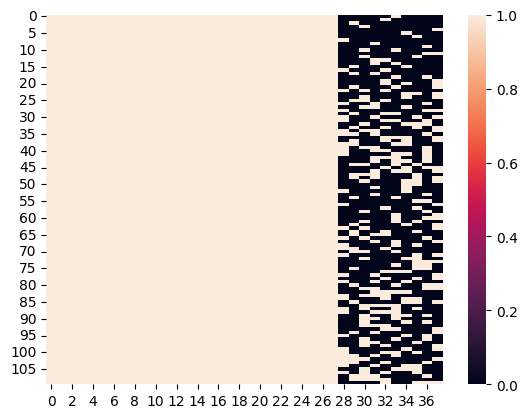

In [15]:
# Heatmap of the medium (conditions, compounds)
# In this case, the medium is a binary matrix for presence or absence (0 or 1)
sns.heatmap(pd.DataFrame(X))
plt.show()

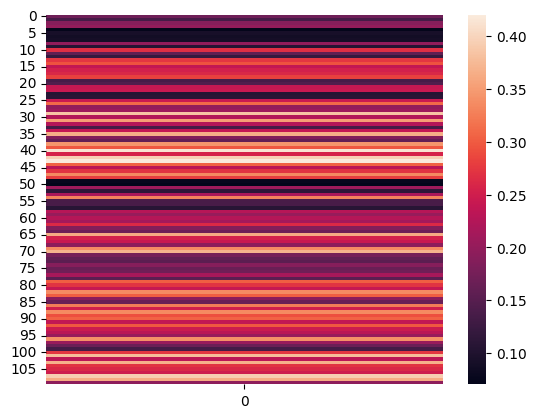

In [16]:
# Heatmap of the growth (conditions)
sns.heatmap(pd.DataFrame(Y))
plt.show()

In [17]:
# Get parameter object for reservoir training set from a medium file
# 'method' is pFBA because this file contains parameters for random generation
mediumfile = DIRECTORY+'Dataset_input/'+mediumname #.csv
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        method='pFBA',
                        verbose=verbose)

medium: ['EX_pi_e_i', 'EX_co2_e_i', 'EX_fe3_e_i', 'EX_h_e_i', 'EX_mn2_e_i', 'EX_fe2_e_i', 'EX_zn2_e_i', 'EX_mg2_e_i', 'EX_ca2_e_i', 'EX_ni2_e_i', 'EX_cu2_e_i', 'EX_sel_e_i', 'EX_cobalt2_e_i', 'EX_h2o_e_i', 'EX_mobd_e_i', 'EX_so4_e_i', 'EX_nh4_e_i', 'EX_k_e_i', 'EX_na1_e_i', 'EX_cl_e_i', 'EX_o2_e_i', 'EX_tungs_e_i', 'EX_slnt_e_i', 'EX_glyc_e_i', 'EX_ala__L_e_i', 'EX_pro__L_e_i', 'EX_thr__L_e_i', 'EX_gly_e_i', 'EX_rib__D_e_i', 'EX_malt_e_i', 'EX_melib_e_i', 'EX_tre_e_i', 'EX_fru_e_i', 'EX_gal_e_i', 'EX_ac_e_i', 'EX_lac__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i']
levmed: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0]
valmed: [2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2]
ratmed: 0.0
objective

#### Explanation of parameters

- `levmed` (Level Medium): Number of discrete levels each medium flux can take.
    - `levmed[i]` <= 1: Minimum medium (always on at a fixed value).
    - `levmed[i]` > 1: Variable medium (can be turned on/off with multiple levels).

- `valmed` (Value Medium): Maximum value each medium flux can take. Used to compute the actual flux value when a variable medium is turned on.

- `ratmed` (Ratio Medium): Ratio/probability of variable medium fluxes being turned on during random generation.

When `method=EXP` these random generation parameters aren't needed.

In [18]:
# Create varmed: the list of variable compound IDs, based on experimental file (X)
varmed = {}
for i in range(X.shape[0]):  # Loop through 110 experimental conditions
    varmed[i] = []
    for j in range(X.shape[1]): # Loop through 38 medium compounds
        if parameter.levmed[j] > 1 and X[i,j] > 0:
            varmed[i].append(parameter.medium[j])
varmed = list(varmed.values())

print(f"\nvarmed len: {len(varmed)}")
print(varmed)


varmed len: 110
[['EX_gal_e_i'], ['EX_fru_e_i'], ['EX_malt_e_i'], ['EX_melib_e_i'], ['EX_pyr_e_i'], ['EX_ac_e_i'], ['EX_lac__D_e_i'], ['EX_rib__D_e_i'], ['EX_tre_e_i'], ['EX_succ_e_i'], ['EX_melib_e_i', 'EX_gal_e_i'], ['EX_succ_e_i', 'EX_pyr_e_i'], ['EX_melib_e_i', 'EX_lac__D_e_i'], ['EX_tre_e_i', 'EX_fru_e_i'], ['EX_tre_e_i', 'EX_gal_e_i'], ['EX_malt_e_i', 'EX_ac_e_i'], ['EX_rib__D_e_i', 'EX_fru_e_i'], ['EX_malt_e_i', 'EX_tre_e_i'], ['EX_gal_e_i', 'EX_succ_e_i'], ['EX_fru_e_i', 'EX_pyr_e_i'], ['EX_fru_e_i', 'EX_ac_e_i', 'EX_pyr_e_i'], ['EX_malt_e_i', 'EX_gal_e_i', 'EX_pyr_e_i'], ['EX_rib__D_e_i', 'EX_melib_e_i', 'EX_fru_e_i'], ['EX_ac_e_i', 'EX_lac__D_e_i', 'EX_pyr_e_i'], ['EX_melib_e_i', 'EX_ac_e_i', 'EX_pyr_e_i'], ['EX_malt_e_i', 'EX_melib_e_i', 'EX_fru_e_i'], ['EX_rib__D_e_i', 'EX_tre_e_i', 'EX_succ_e_i'], ['EX_melib_e_i', 'EX_tre_e_i', 'EX_ac_e_i'], ['EX_rib__D_e_i', 'EX_succ_e_i', 'EX_pyr_e_i'], ['EX_malt_e_i', 'EX_fru_e_i', 'EX_gal_e_i'], ['EX_rib__D_e_i', 'EX_tre_e_i', 'EX_lac

#### Explanation of `varmed`
`varmed` is a list that contains the compound IDs present per condition
- `varmed[0] = ['EX_gal_e_i']`: Condition 0 has only galactose as a variable medium
- `varmed[10] = ['EX_melib_e_i', 'EX_gal_e_i']`: Condition 10 has melibiose and galactose

If the compound exists in the medium (`if parameter.levmed[j] > 1`) and is present in the reference medium matrix (`and X[i,j] > 0`) it'll be appended to this list.

### 2.2. Creating the `FBA-simulated` dataset

Takes a while to run (~320 mins)

For each condition (`varmed[i]`) generate `size_i` iterations of FBA-simulated data.

e.g. if `varmed[i] = 110` and `size_i = 100`, the `trainingsize = 11,000` (110x100)

In [19]:
# Get a Cobra training set constrained by varmed
for i in range(X.shape[0]): 
    parameter.get(sample_size=size_i, varmed=varmed[i], verbose=True) 

sample: 0
pass (varmed, obj): ['EX_gal_e_i'] 0.09339486031638583
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.09339486031638485
sample: 1
pass (varmed, obj): ['EX_gal_e_i'] 0.09864436780342009
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.09864436780342009
sample: 2
pass (varmed, obj): ['EX_gal_e_i'] 0.13974434548912149
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.13974434548912149
sample: 3
pass (varmed, obj): ['EX_gal_e_i'] 0.10975073487276607
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.10975073487276607
sample: 4
pass (varmed, obj): ['EX_gal_e_i'] 0.16057328719817257
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.16057328719817257
sample: 5
pass (varmed, obj): ['EX_gal_e_i'] 0.16390591787162329
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.16390591787162329
sample: 6
pass (varmed, obj): ['EX_gal_e_i'] 0.11058389303794224
primal objectif = ['BIOMASS_Ec_iML1515_core_75p37M'] pFBA 0.11058389303794224

In [20]:
# Saving file
trainingfile  = DIRECTORY+'Dataset_model/iML1515_'+parameter.mediumbound
parameter.save(trainingfile, reduce=reduce)

#### Explanation of `reduce`

The `reduce` parameter removes unused reactions and metabolites to create a smaller, more efficient model. It identifies reactions that can be safely removed, which must: 
- have zero flux across all training samples
- AND are not in the medium
- AND are not in the measured reaction

In [21]:
# Verifying

from Library.Build_Dataset import *

trainingfile = DIRECTORY+'Dataset_model/iML1515_UB'
parameter = TrainingSet()
parameter.load(trainingfile)
print(trainingfile)
parameter.printout()

./Dataset_model/iML1515_UB
model file name: ./Dataset_model/iML1515_UB
reduced model: False
medium file name: ./Dataset_input/iML1515
medium bound: UB
list of reactions in objective: ['BIOMASS_Ec_iML1515_core_75p37M']
method: pFBA
trainingsize: 11000
list of medium reactions: 38
list of medium levels: 38
list of medium values: 38
ratio of variable medium turned on: 0.0
list of measured reactions: 3682
Stoichiometric matrix (1877, 3682)
Boundary matrix from reactions to medium: (38, 3682)
Measurement matrix from reaction to measures: (3682, 3682)
Reaction to metabolite matrix: (1877, 3682)
Metabolite to reaction matrix: (3682, 1877)
Training set X: (11000, 38)
Training set Y: (11000, 3682)
S_int matrix (1845, 3682)
S_ext matrix (3682, 7436)
Q matrix (3682, 1845)
P matrix (3682, 3682)
b_int vector (1845,)
b_ext vector (11000, 7436)
Sb matrix (3682, 1877)
c vector (3682,)


In [22]:
# X training matrix (trainingsize, compounds)
X_fba_simulated = parameter.X.copy()
print("X shape (conditions, compounds):")
print(X_fba_simulated.shape)
print("X:")
print(f"{X_fba_simulated}\n")

# Y training matrix (trainingsize, flux values)
Y_fba_simulated = parameter.Y.copy()
print("Y shape (conditions, flux values):")
print(Y_fba_simulated.shape)
print("Y:")
print(f"{Y_fba_simulated}")

X shape (conditions, compounds):
(11000, 38)
X:
[[ 2.2         2.2         2.2        ...  0.          0.
   0.        ]
 [ 2.2         2.2         2.2        ...  0.          0.
   0.        ]
 [ 2.2         2.2         2.2        ...  0.          0.
   0.        ]
 ...
 [ 2.2         2.2         2.2        ...  8.33333333 10.22222222
   0.11111111]
 [ 2.2         2.2         2.2        ...  7.22222222  8.77777778
   9.44444444]
 [ 2.2         2.2         2.2        ...  7.66666667  5.44444444
   9.88888889]]

Y shape (conditions, flux values):
(11000, 3682)
Y:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


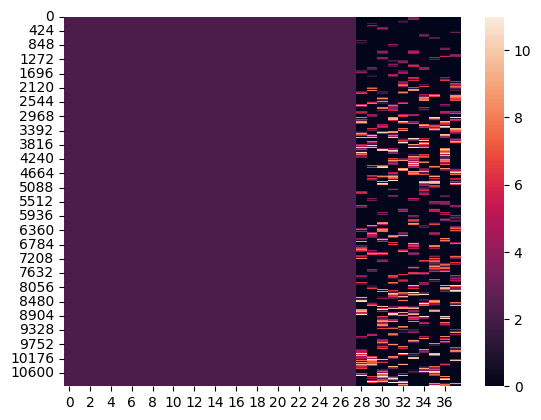

In [23]:
# Heatmap of X (trainingsize, compounds)
sns.heatmap(pd.DataFrame(parameter.X))
plt.show()

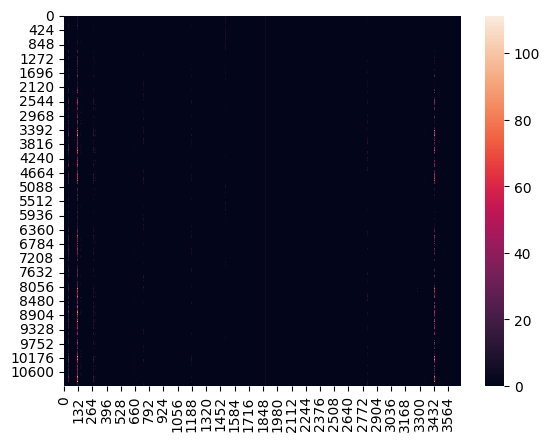

In [24]:
# Heatmap of Y (trainingsize, flux values)
sns.heatmap(pd.DataFrame(parameter.Y))
plt.show()

## Step 3. Build Artificial Metabolic Network (AMN)

This step aims to create a hybrid AMN model for learning on the COBRApy-generated dataset (see Step 2.2. above).

This will be used as the 'Reservoir Model' in the pipeline.

5-fold cross-validation is performed on 90% of the data and an independent test-set of 10% of the data.

\* Process from `Tutorial.ipynb` AMN cell

In [25]:
from Library.Build_Model import *

Using 1 GPU(s)


In [26]:
def printout(filename, Stats, model, time): 
    """
    Printout function for AMN models
    """
    # printing Stats
    print('Stats for %s GPU-time %.4f' % (filename, time))
    print('R2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    print('Q2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.test_objective[0], Stats.test_objective[1],
           Stats.test_loss[0], Stats.test_loss[1]))

Create, train and evaluate AMN_QP model with FBA simulated training set for iML1515


In [27]:
# Parameters
seed = 10
ratio_test = 0.1 # part of the training set removed for test
np.random.seed(seed=seed)  
trainname = 'iML1515_UB' # model, bounds
  
# Create model
trainingfile = DIRECTORY+'Dataset_model/'+trainname
model = Neural_Model(trainingfile = trainingfile, 
                     objective=['BIOMASS_Ec_iML1515_core_75p37M'],  
                     model_type='AMN_QP', 
                     timestep = 4, 
                     learn_rate=0.01,
                     scaler=True,
                     n_hidden = 1, 
                     hidden_dim = 50,
                     epochs=500,
                     xfold=5,
                     batch_size=128, # 5
                     es=True, # added early stopping
                     verbose=True)

# Split training and test set using ratio_test
ID = np.random.choice(model.X.shape[0], 
                      size=int(model.X.shape[0]*ratio_test), 
                      replace=False)
Xtest,  Ytest  = model.X[ID,:], model.Y[ID,:]
Xtrain, Ytrain = np.delete(model.X, ID, axis=0), np.delete(model.Y, ID, axis=0)
model.printout()

number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
training file: ./Dataset_model/iML1515_UB
model type: AMN_QP
model scaler: 1.0
model input dim: 38
model output dim: 1
model medium bound: UB
timestep: 4
training set size (11000, 38) (11000, 1)
nbr hidden layer: 1
hidden layer size: 50
activation function: relu
gradient learn rate: 0.01
gradient decay rate: 0.9
training epochs: 500
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 128
training validation iter: 0
training xfold: 5
training early stopping: True


In [ ]:
# Train and evaluate (~35 mins)
reservoirname = trainname+'_'+model.model_type
reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
start_time = time.time()
model.X, model.Y = Xtrain, Ytrain
reservoir, pred, stats, _ = train_evaluate_model(model, verbose=2)
delta_time = time.time() - start_time

AMN scaler 11.0
QP input shape (9900, 38) (9900, 4)
-------train [   0    1    2 ... 9897 9898 9899] (7920, 38) (7920, 4)
-------test  [   7    8   14 ... 9886 9891 9896] (1980, 38) (1980, 4)
----------------------------------- AMN_QP
Dense layer n_hidden, hidden_dim, output_dim, activation, trainable: 1 50 3682 relu True
Instructions for updating:
Use `tf.linalg.matmul` instead
AMN output shapes for PoutV, SV, PinV, Vpos, V, outputs (None, 1) (None, 1) (None, 1) (None, 1) (None, 3682) (None, 7368)
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 38)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 50)                   1950      ['input_1[0][0]']

I0000 00:00:1769484119.772823 1129895 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 [==============================] - 18s 228ms/step - loss: 0.0116 - my_r2: 0.5978 - val_loss: 0.0051 - val_my_r2: 0.6945
Epoch 2/500
62/62 [==============================] - 14s 226ms/step - loss: 0.0031 - my_r2: 0.8896 - val_loss: 7.5103e-04 - val_my_r2: 0.9516
Epoch 3/500
62/62 [==============================] - 14s 225ms/step - loss: 6.7023e-04 - my_r2: 0.9764 - val_loss: 7.5716e-05 - val_my_r2: 0.9964
Epoch 4/500
62/62 [==============================] - 14s 225ms/step - loss: 4.9512e-04 - my_r2: 0.9827 - val_loss: 4.5363e-05 - val_my_r2: 0.9975
Epoch 5/500
62/62 [==============================] - 14s 225ms/step - loss: 4.5508e-04 - my_r2: 0.9839 - val_loss: 3.9142e-05 - val_my_r2: 0.9980
Epoch 6/500
62/62 [==============================] - 14s 224ms/step - loss: 4.4678e-04 - my_r2: 0.9843 - val_loss: 2.7729e-05 - val_my_r2: 0.9982
Epoch 7/500
62/62 [==============================] - 14s 225ms/step - loss: 3.9850e-04 - my_r2: 0.9859 - val_loss: 3.1109e-05 - val_my_r2: 0.9984
Ep

In [29]:
# Printing cross-validation results
printout(reservoirname, stats, model, delta_time)

Stats for iML1515_UB_AMN_QP GPU-time 2019.9222
R2 = 0.9971 (+/- 0.0009) Constraint = 0.0000 (+/- 0.0000)
Q2 = 0.9970 (+/- 0.0008) Constraint = 0.0000 (+/- 0.0000)


In [ ]:
# Save, reload and run idependent test set (~10 mins)
reservoir.save(reservoirfile)
reservoir.load(reservoirfile)
reservoir.printout()
if len(Xtest) > 0:
    start_time = time.time()
    reservoir.X, reservoir.Y = Xtest, Ytest
    X, Y = model_input(reservoir, verbose=True)
    pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=2)
    delta_time = time.time() - start_time
    printout('Test set', stats, model, delta_time)

./Reservoir/iML1515_UB_AMN_QP_param.csv


/nfs/homes/chinasse/amn_release/.venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


training file: ./Dataset_model/iML1515_UB
model type: AMN_QP
model scaler: 11.0
model input dim: 38
model output dim: 7368
model medium bound: UB
timestep: 4
training set size (11000, 38) (11000, 1)
nbr hidden layer: 1
hidden layer size: 50
activation function: relu
gradient learn rate: 0.01
gradient decay rate: 0.9
training epochs: 500
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 128
training validation iter: 0
training xfold: 5
training early stopping: True
AMN scaler 11.0
QP input shape (1100, 38) (1100, 4)
35/35 [==============================] - 120s 103ms/step
---------- 1
Loss out on V0:  0.006668129
Loss constraint on V0:  5.2219975e-06
Loss all on V0:  2.5543706e-05
Loss out on Vf:  0.006669767
Loss constraint on Vf:  5.2218306e-06
Loss all on Vf:  2.5547864e-05
Distance V0 to Vf 0.000113: 
Stats for Test set GPU-time 120.5869
R2 = 0.9976 (+/- 0.0000) Constraint = 0.0000 (+/- 0.0000)
Q2 = 0.9976 (+/- 0.0000) Constraint = 0.00

## 4. Get predictions using experimental data + reservoir model

\* Process from `Build_Model_RC.ipynb` code cell 3

In [ ]:
# Create, train and evaluate reservoir models on experimental training set 
# Repeat the process with different seeds (~90 mins)

seed = 10
Maxloop, Q2, PRED = 3, [], []  
for Nloop in range(Maxloop):
    # Parameters
    seed = Nloop
    np.random.seed(seed=seed)  
    trainname = 'iML1515_EXP'
    reservoirname = 'iML1515_UB_AMN_QP'
  
    # Create model 
    trainingfile = DIRECTORY+'Dataset_input/'+trainname
    reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
    X, Y = read_XY(trainingfile, 38)
    model = RC_Model(reservoirfile = reservoirfile, 
                     X=X, Y=Y, 
                     n_hidden_prior = 1, 
                     hidden_dim_prior = 500, 
                     activation_prior = 'relu',
                     epochs = 500, 
                     train_rate = 1.0e-3,
                     batch_size=128, # 5
                     xfold = 5,
                     es=False, # early stopping
                     verbose=True)
    model.printout()

    # Train and evaluate
    start_time = time.time()
    reservoir, pred, stats, _ = train_evaluate_model(model, verbose=2)
    delta_time = time.time() - start_time

    # Printing cross-validation results
    printout(reservoirname, stats, model, delta_time)
    r2 = r2_score(model.Y, pred[:,0], multioutput='variance_weighted')
    print('Iter', Nloop, 'Collated Q2', r2)
    Q2.append(r2)
    PRED.append(pred)

number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
RC reservoir file: ./Reservoir/iML1515_UB_AMN_QP
RC model type: RC
RC scaler: 0.0
RC model input dim: 38
RC model output dim: 1
RC model medium bound: UB
training set size (110, 38) (110, 1)
reservoir S, Pin, Pout matrices (1877, 3682) (38, 3682) (1, 3682)
RC training epochs: 500
RC training regression: True
RC training learn rate: 0.001
RC training dropout: 0.25
RC training batch size: 128
RC training validation iter: 0
RC training xfold: 5
RC training early stopping: False
--------prior network --------
training file: None
model type: ANN_Dense
model scaler: 0.0
model input dim: 10
model output dim: 10
model medium bound: 
timestep: 0
no training set provided
nbr hidden layer: 1
hidden layer size: 500
activation function: relu
--------reservoir network-----
training file: ./Dataset_model/iML1515_UB
model type: AMN_QP
model scaler: 11.0
model input dim: 38
model output dim: 7368
model medium bo

In [ ]:
# Some printings and savings
Q2, PRED = np.asarray(Q2), np.asarray(PRED)

print("")
print(PRED.shape)

obj = PRED[:,:,0]

print('Averaged Q2 = %.4f (+/- %.4f)' % (np.mean(Q2), np.std(Q2)))
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_Q2.csv'
np.savetxt(filename, Q2, delimiter=',')
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_PRED.csv'
np.savetxt(filename, obj, delimiter=',')

(3, 110, 3724)
Averaged Q2 = 0.9703 (+/- 0.0026)
Loss SV average 0.0043 max 0.0067
Loss Vin average 0.0000 max 0.0000
Loss Vpos average 0.0000 max 0.0000


In [ ]:
# Saving input / output of the first prediction for Cobra runs
pred, obj = PRED[0], pred[:,0]
Loss_SV, Loss_Vin, Loss_Vpos = pred[:,1], pred[:,2], pred[:,3]
print('Loss SV average %.4f max %.4f' % (np.mean(Loss_SV), np.max(Loss_SV)))
print('Loss Vin average %.4f max %.4f' % (np.mean(Loss_Vin), np.max(Loss_Vin)))
print('Loss Vpos average %.4f max %.4f' % (np.mean(Loss_Vpos), np.max(Loss_Vpos)))

V = pred[:, 4:4+model.S.shape[1]]
Vin_pre_scaling = pred[:, 4+model.S.shape[1]:]
Vin = model.res.scaler * Vin_pre_scaling # rescale back for Cobra
XY = np.concatenate((Vin, Y), axis=1)
filename = DIRECTORY+'Result/'+reservoirname+'_'\
+str(model.model_type)+'_solution_for_Cobra.csv'
np.savetxt(filename, XY, delimiter=',')

## 5. Use RC predictions as input for COBRApy

The goal is to get a better growth rate estimate (comparing COBRApy predicted vs experimental value) when constraining the GEM with predicted medium fluxes.

\* Process from `Build_Dataset.ipynb` AMN cell

In [ ]:
# This cell run FBA on a provided training and compute R2 between
# provided objective and calculated objective
# For exprimental training set medium input fluxes can be scaled by a value

from Library.Build_Dataset import *
from sklearn.metrics import r2_score

# Parameters
seed = 10
np.random.seed(seed=seed)  
cobraname = 'iML1515_EXP'  # name of the model 
mediumbound = 'UB' # a must, exact bounds unknown
mediumname = 'iML1515_UB_AMN_QP_RC_solution_for_Cobra' # for running Cobra with RC predictions as inputs
#mediumname = 'iML1515_UB_AMN_QP_RC_AMN_solution_for_Cobra_pred' # for running Cobra with RC predictions as inputs
method = 'EXP' # FBA, pFBA or EXP

# Get data
cobrafile =  DIRECTORY+'Dataset_input/'+cobraname
mediumfile = DIRECTORY+'Dataset_input/'+mediumname
parameter = TrainingSet(cobraname=cobrafile, 
                        mediumname=mediumfile, 
                        mediumbound=mediumbound, 
                        mediumsize=38, 
                        method=method,
                        verbose=True)
scaler_list = [1] # best scaler for RC EXP input

# Regression cobra vs. true values
L = parameter.X.shape[0]
for scaler in scaler_list:
    Y = {}
    for i in range(L):
        inf = {r.id: 0 for r in parameter.model.reactions}
        for j in range(len(parameter.medium)):
            print(j, parameter.medium[j],parameter.X[i,j], len(parameter.model.reactions))
            eps = 1.0e-4 if parameter.X[i,j] < 1.0e-4 else 0
            inf[parameter.medium[j]] = scaler * parameter.X[i,j] + eps
        out,Y[i] = run_cobra(parameter.model, parameter.objective, inf, method='pFBA', verbose=False)
        print("%d %.4f %.4f" % (i, parameter.Y[i].item(), Y[i].item()))

    Y = list(Y.values())
    r2 = r2_score(parameter.Y[0:L], Y[0:L], multioutput='variance_weighted')
    print('scaler %.2f R2 %.4f ' % (scaler, r2))

0 EX_pi_e_i 2.2 543
1 EX_co2_e_i 2.2 543
2 EX_fe3_e_i 2.2 543
3 EX_h_e_i 2.2 543
4 EX_mn2_e_i 2.2 543
5 EX_fe2_e_i 2.2 543
6 EX_zn2_e_i 2.2 543
7 EX_mg2_e_i 2.2 543
8 EX_ca2_e_i 2.2 543
9 EX_ni2_e_i 2.2 543
10 EX_cu2_e_i 2.2 543
11 EX_sel_e_i 2.2 543
12 EX_cobalt2_e_i 2.2 543
13 EX_h2o_e_i 2.2 543
14 EX_mobd_e_i 2.2 543
15 EX_so4_e_i 2.2 543
16 EX_nh4_e_i 2.2 543
17 EX_k_e_i 2.2 543
18 EX_na1_e_i 2.2 543
19 EX_cl_e_i 2.2 543
20 EX_o2_e_i 2.2 543
21 EX_tungs_e_i 2.2 543
22 EX_slnt_e_i 2.2 543
23 EX_glyc_e_i 2.2 543
24 EX_ala__L_e_i 2.2 543
25 EX_pro__L_e_i 2.2 543
26 EX_thr__L_e_i 2.2 543
27 EX_gly_e_i 2.2 543
28 EX_rib__D_e_i 0.0 543
29 EX_malt_e_i 0.0 543
30 EX_melib_e_i 0.0 543
31 EX_tre_e_i 0.0 543
32 EX_fru_e_i 0.0 543
33 EX_gal_e_i 5.55 543
34 EX_ac_e_i 0.0 543
35 EX_lac__D_e_i 0.0 543
36 EX_succ_e_i 0.0 543
37 EX_pyr_e_i 0.0 543
0 0.1700 0.1896
0 EX_pi_e_i 2.2 543
1 EX_co2_e_i 2.2 543
2 EX_fe3_e_i 2.2 543
3 EX_h_e_i 2.2 543
4 EX_mn2_e_i 2.2 543
5 EX_fe2_e_i 2.2 543
6 EX_zn2_e_i 2